<a href="https://colab.research.google.com/github/nguyenminhthu20060906-cell/DS-CU-I-K-/blob/main/DS_cu%E1%BB%91i_k%C3%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Mục tiêu nghiên cứu**:
- Xây dựng profile hành vi mua sắm của khách hàng thông qua phân tích RFM
- Phân khúc khách hàng thành các nhóm giá trị phân biệt bằng phương pháp phân cụm không giám sát
- Phân tích hành vi theo thời gian qua cohort retention analysis
- Xây dựng mô hình phân loại để dự đoán phân khúc khách hàng dựa trên đặc trưng hành vi
Kiểm định thống kê để xác nhận sự khác biệt có ý nghĩa giữa các phân khúc


# Data Preparation

In [1]:
import pandas as pd
import seaborn as sns

## Import Dataset


In [2]:
import pandas as pd

url = "https://drive.google.com/uc?id=11yPXynkixdhdOA-5cSC-tUoCEh4Jh1as"

df = pd.read_csv(url)

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df_coppy = df.copy()

## Data Overview

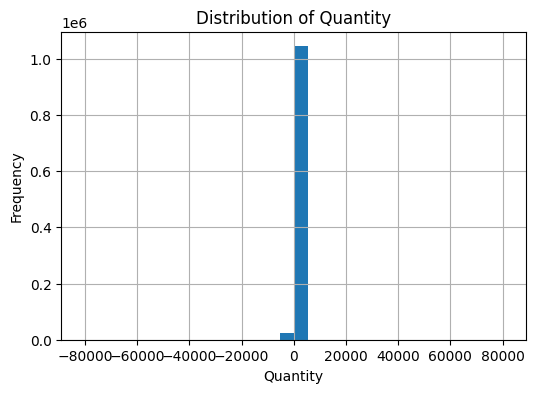

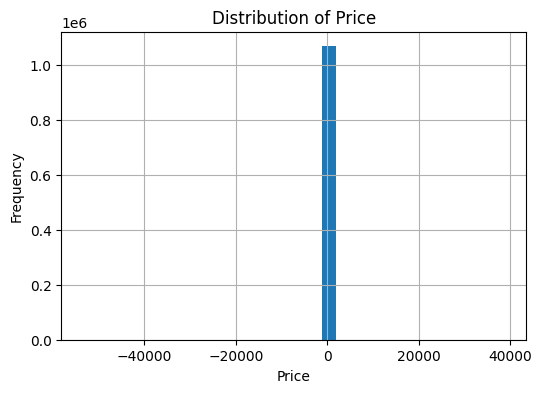

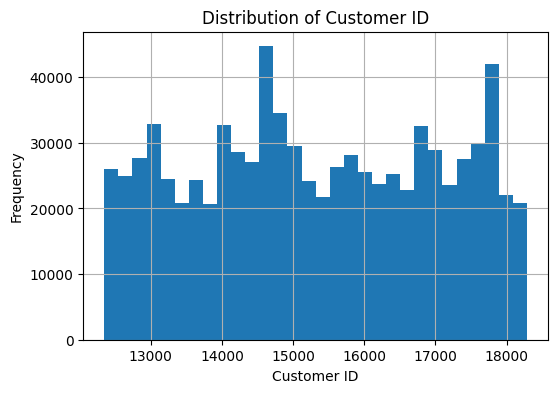

In [4]:
import matplotlib.pyplot as plt

cols = df.select_dtypes(include='number').columns

for col in cols:

    plt.figure(figsize=(6,4))

    df[col].hist(bins=30)

    plt.title(f"Distribution of {col}")

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.show()

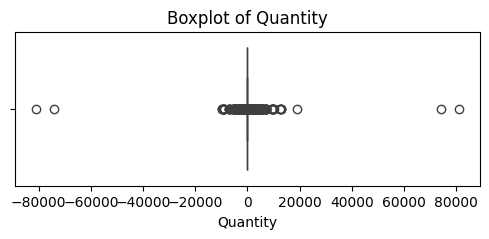

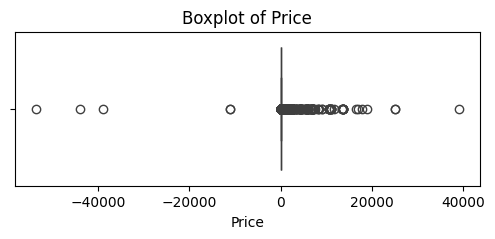

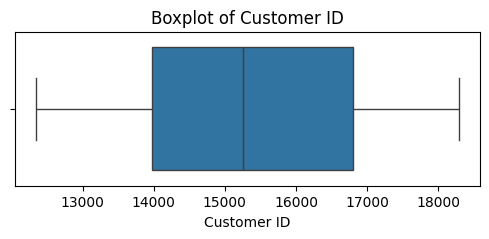

In [5]:
cols = df.select_dtypes(include='number').columns

for col in cols:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot of {col}")

    plt.show()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [7]:
#Chuyển invoice date về dạng ngày tháng
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Customer ID'] = df['Customer ID'].astype('object')

In [8]:
df.describe()

,Quantity,InvoiceDate,Price
count,1.067371e+06,1067371,1.067371e+06
mean,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00
min,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04
25%,1.000000e+00,2010-07-09 09:46:00,1.250000e+00
50%,3.000000e+00,2010-12-07 15:28:00,2.100000e+00
75%,1.000000e+01,2011-07-22 10:23:00,4.150000e+00
max,8.099500e+04,2011-12-09 12:50:00,3.897000e+04
std,1.727058e+02,NaN,1.235531e+02


In [9]:
df.nunique()

,0
Invoice,53628
StockCode,5305
Description,5698
Quantity,1057
InvoiceDate,47635
Price,2807
Customer ID,5942
Country,43


In [10]:
df[df['Quantity'] <0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


In [11]:
#Xoá bỏ các cột có quantity âm
df = df[df['Quantity'] > 0]

In [12]:
#Kiểm tra số dòng bị trùng
df.duplicated().sum()

np.int64(33881)

In [13]:
#Xoá các dòng bị trùng
df.drop_duplicates(inplace=True)

## Missing Value Analysis

In [14]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,1642
Quantity,0
InvoiceDate,0
Price,0
Customer ID,231045
Country,0


In [15]:
missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percent": (df.isnull().sum() / len(df)) * 100
})

print(missing_table)

             Missing Count  Missing Percent
Invoice                  0         0.000000
StockCode                0         0.000000
Description           1642         0.162487
Quantity                 0         0.000000
InvoiceDate              0         0.000000
Price                    0         0.000000
Customer ID         231045        22.863519
Country                  0         0.000000


Vì mục tiêu bài toán là:
- tính RFM,
- cohort retention,
- customer segmentation,
- classification theo customer behavior
--> nên ta xoá những giá trị CustomerID bị null vì không biết khách hàng đó là ai đẻ phân tích về sau

In [16]:
df= df.dropna(subset =['Customer ID'])

## Outlier & Business Rule Filtering

- Các giao dịch có mã hóa đơn (InvoiceNo) bắt đầu bằng ký tự “C” được xem là các đơn hàng bị hủy hoặc hoàn trả. Những giao dịch này không phản ánh hành vi mua hàng thực tế của khách hàng nên được tách riêng khỏi tập dữ liệu chính để tránh ảnh hưởng đến quá trình phân tích hành vi và tính toán các chỉ số RFM.
- Ngoài ra, các giao dịch với số lượng hoặc số tiền lớn cũng đóng vai trò quan trọng trong việc phân loại khách hàng theo RFM nên ta sẽ giữ nguyên và không loại bỏ

In [17]:
rows_before = len(df)

In [18]:
df_cancel = df[df['Invoice'].astype(str).str.startswith("c")]

In [19]:
df["Invoice"].dtype

dtype('O')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779495 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779495 non-null  object        
 1   StockCode    779495 non-null  object        
 2   Description  779495 non-null  object        
 3   Quantity     779495 non-null  int64         
 4   InvoiceDate  779495 non-null  datetime64[ns]
 5   Price        779495 non-null  float64       
 6   Customer ID  779495 non-null  object        
 7   Country      779495 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 53.5+ MB


In [21]:
(df['Price'] < 0).sum()

np.int64(0)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 779495 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779495 non-null  object        
 1   StockCode    779495 non-null  object        
 2   Description  779495 non-null  object        
 3   Quantity     779495 non-null  int64         
 4   InvoiceDate  779495 non-null  datetime64[ns]
 5   Price        779495 non-null  float64       
 6   Customer ID  779495 non-null  object        
 7   Country      779495 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 53.5+ MB


Các biến giao dịch như Quantity, Frequency và Monetary có phân phối lệch phải rất mạnh do đặc thù của dữ liệu bán lẻ trực tuyến, trong đó một số khách hàng hoặc đơn hàng có giá trị rất lớn. Tuy nhiên, các giá trị cực lớn này không nhất thiết là dữ liệu lỗi mà có thể phản ánh các khách hàng giá trị cao hoặc các giao dịch mua số lượng lớn thực tế.

Vì mục tiêu của nghiên cứu là phân tích hành vi khách hàng và phân khúc giá trị khách hàng, việc loại bỏ toàn bộ outlier theo phương pháp thống kê có thể làm mất các nhóm khách hàng quan trọng về mặt kinh doanh. Do đó, nghiên cứu không áp dụng loại bỏ outlier hàng loạt mà sử dụng log transformation nhằm giảm độ lệch phân phối nhưng vẫn giữ được thông tin hành vi có ý nghĩa.

## Feature Engineering: TotalSales & Cancellation Rate


In [23]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [24]:
df['revenue'] = df['Price']*df['Quantity']

# **RQ1**

Dựa trên hành vi giao dịch (Recency, Frequency, Monetary), có thể phân khúc khách hàng thành các nhóm có đặc điểm hành vi phân biệt rõ ràng và có ý nghĩa kinh doanh không?

Để trả lời câu hỏi này, nghiên cứu sử dụng bộ dữ liệu Online Retail II nhằm xây dựng bộ đặc trưng hành vi khách hàng dựa trên mô hình RFM, bao gồm: Độ gần đây của giao dịch (Recency), Tần suất mua hàng (Frequency) và Tổng giá trị chi tiêu (Monetary). Sau khi chuẩn hóa dữ liệu, phương pháp phân cụm không giám sát K-Means sẽ được áp dụng để khám phá các nhóm khách hàng có hành vi mua sắm tương đồng. Kết quả thu được không chỉ giúp nhận diện các phân khúc khách hàng quan trọng như khách hàng trung thành, khách hàng giá trị cao hay khách hàng có nguy cơ rời bỏ, mà còn cho thấy tỷ trọng doanh thu và đặc điểm hành vi đặc trưng của từng nhóm. Qua đó, nghiên cứu hỗ trợ doanh nghiệp hiểu rõ hơn cấu trúc khách hàng và xây dựng chiến lược chăm sóc phù hợp cho từng phân khúc.


## Tính RFM

In [25]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [26]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [27]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'revenue': 'sum'
})

In [28]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm = rfm.reset_index()

In [29]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [30]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000,5881.000000
mean,15314.674205,201.457745,6.287196,2954.396237
std,1715.429759,209.474135,13.012879,14437.322635
min,12346.000000,1.000000,1.000000,0.000000
25%,13833.000000,26.000000,1.000000,341.900000
50%,15313.000000,96.000000,3.000000,865.600000
75%,16797.000000,380.000000,7.000000,2247.720000
max,18287.000000,739.000000,398.000000,580987.040000


## Visualize customer segmentation

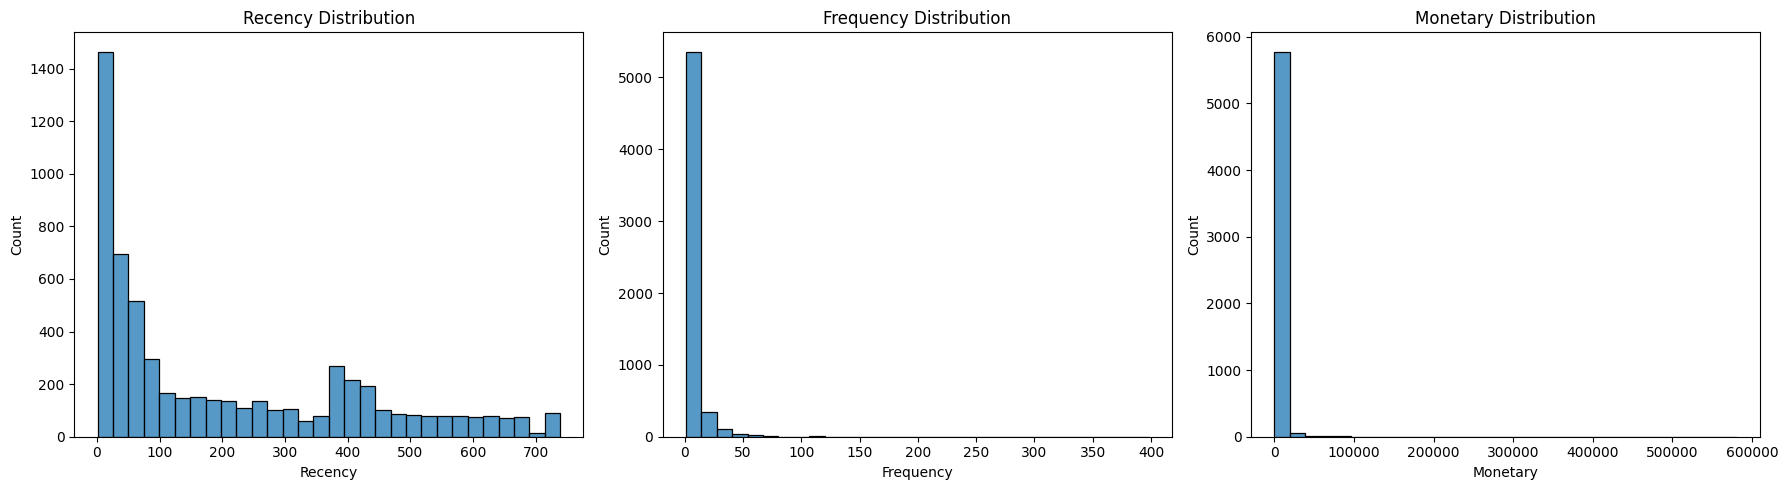

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], bins=30, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm['Frequency'], bins=30, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm['Monetary'], bins=30, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

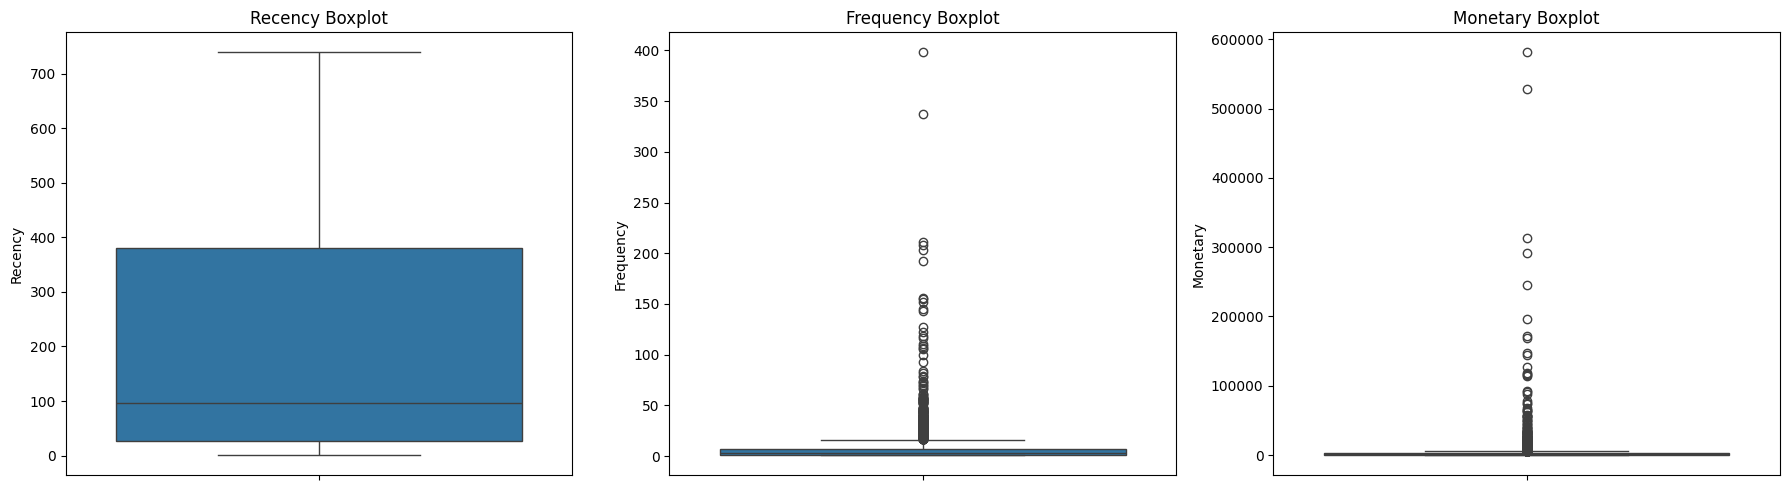

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=rfm['Recency'], ax=axes[0])
axes[0].set_title("Recency Boxplot")

sns.boxplot(y=rfm['Frequency'], ax=axes[1])
axes[1].set_title("Frequency Boxplot")

sns.boxplot(y=rfm['Monetary'], ax=axes[2])
axes[2].set_title("Monetary Boxplot")

plt.tight_layout()
plt.show()

In [33]:
print("Recency skewness:", rfm['Recency'].skew())
print("Frequency skewness:", rfm['Frequency'].skew())
print("Monetary skewness:", rfm['Monetary'].skew())

Recency skewness: 0.8867922456229036
Frequency skewness: 12.653997472659995
Monetary skewness: 25.0760882762493


**Nhận xét**: Các biến RFM đều có phân phối lệch phải, trong đó Frequency và Monetary thể hiện mức độ skewness rất cao (12.65 và 25.07), cho thấy dữ liệu mang đặc trưng điển hình của hành vi mua sắm trong bán lẻ trực tuyến khi mà phần lớn khách hàng chỉ mua ít lần và chi tiêu thấp, trong khi một nhóm nhỏ khách hàng đóng góp phần lớn doanh thu (Pareto principle).

## Log Transform (Để giảm skew)

Do các biến RFM có phân phối lệch phải mạnh (skewness lớn), nghiên cứu áp dụng phép biến đổi log(1 + x) để giảm độ lệch và hạn chế ảnh hưởng của giá trị ngoại lai. Sau đó, dữ liệu được chuẩn hóa bằng StandardScaler để đảm bảo các biến có cùng thang đo trước khi áp dụng K-Means.

In [34]:
import numpy as np
#Tạo bảng copy để đỡ mất dữ liệu
rfm_log = rfm[['Recency','Frequency','Monetary']].copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

In [35]:
#scale dữ liệu về phân phối chuẩn
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

In [36]:
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency','Frequency','Monetary'])

In [37]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,5.881000e+03,5.881000e+03,5.881000e+03
mean,-1.510251e-16,1.377349e-16,2.754697e-16
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-2.411921e+00,-1.057568e+00,-4.889339e+00
25%,-7.429922e-01,-1.057568e+00,-7.004181e-01
50%,7.706343e-02,-2.012239e-01,-3.510745e-02
75%,9.543261e-01,6.551203e-01,6.491479e-01
max,1.380009e+00,5.485112e+00,4.634939e+00


## EDA Briviate


1. Scatter plot: Recency vs Monetary

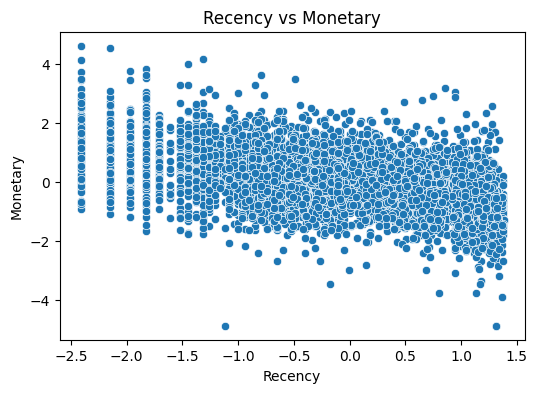

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.scatterplot(data=rfm_scaled, x='Recency', y='Monetary')
plt.title('Recency vs Monetary')
plt.show()

2. Scatter plot: Frequency vs Monetary

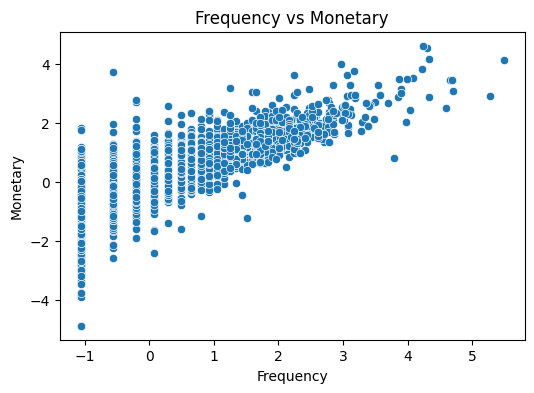

In [39]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=rfm_scaled, x='Frequency', y='Monetary')
plt.title('Frequency vs Monetary')
plt.show()

3. Correlation heatmap

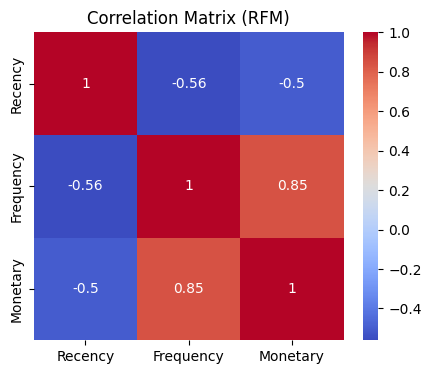

In [40]:
plt.figure(figsize=(5,4))
sns.heatmap(rfm_scaled[['Recency','Frequency','Monetary']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix (RFM)')
plt.show()

In [41]:
#Kiểm tra lại dữ liệu sau khi scale
print(rfm_scaled[['Recency', 'Frequency', 'Monetary']].skew())

Recency     -0.488407
Frequency    1.001904
Monetary     0.212040
dtype: float64


**Nhận xét**: Sau khi áp dụng log transformation và standard scaling, các biến được đưa về cùng thang đo, đảm bảo giả định của K-Means về khoảng cách Euclidean không bị chi phối bởi sự chênh lệch giá trị giữa các biến, đặc biệt là Monetary.

## Elbow Method

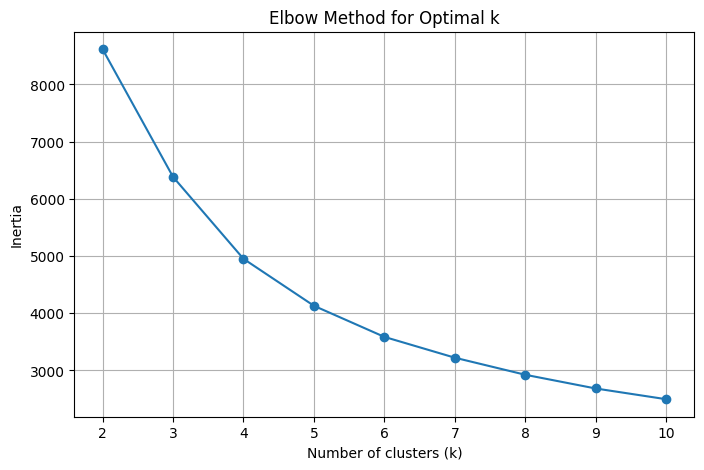

In [42]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# lưu inertia cho từng k
inertia = []

# thử k từ 2 đến 10
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# vẽ elbow curve
plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(K)
plt.grid(True)
plt.show()

## Silhouette Score Analysis

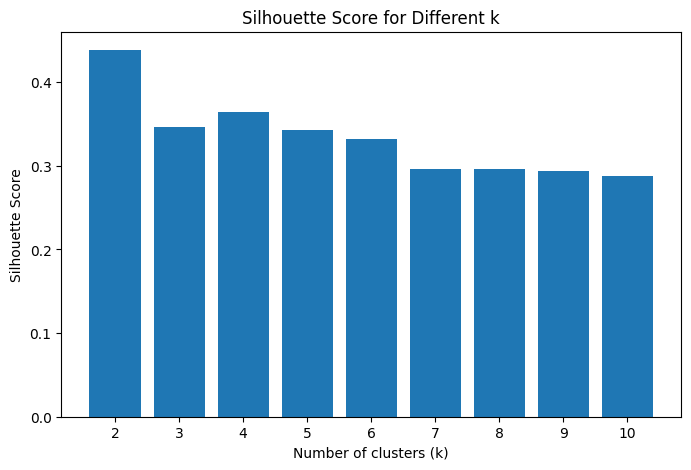

Best k based on silhouette score: 2


In [43]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sil_scores = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    sil_scores.append(score)

# vẽ biểu đồ
plt.figure(figsize=(8,5))
plt.bar(K, sil_scores)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Different k')
plt.xticks(K)
plt.show()

# in ra k tốt nhất
best_k = K[sil_scores.index(max(sil_scores))]
print("Best k based on silhouette score:", best_k)

**Nhận xét**: Sau khi xử lý độ lệch bằng Log Transformation và chuẩn hóa dữ liệu bằng StandardScaler, chúng tôi đã tiến hành thử nghiệm số cụm từ 2 đến 10. Kết quả từ Elbow Method xác định điểm gãy tại $k=4$. Bên cạnh đó Silhouette Score tại $k=4$ đạt giá trị khả quan, đảm bảo tính nhất quán nội tại của các cụm. Do đó, $k=4$ được lựa chọn để tiến hành phân cụm chính thức bằng thuật toán K-Means.

**Note**: Nhóm không chọn $k=2$ vì trong phân tích RFM, $k=2$ là quá nhỏ để chia ra các tệp khách hàng rõ rệt và có thể bỏ sót nhiều đối tượng, $k=2$ là chưa đủ chi tiết

## K-Means Clustering


In [44]:
from sklearn.cluster import KMeans

# chọn k tối ưu từ silhouette
k = 4

# fit KMeans
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# xem phân bố cluster
rfm['Cluster'].value_counts()

,count
Cluster,
1,1979
0,1463
2,1251
3,1188


**Nhận xét**:
Thông qua mô hình K-Means với k=4, nhóm đã phân tách thành công tập khách hàng thành 4 nhóm hành vi rõ rệt. Đáng chú ý là nhóm Champions (Cụm 3) chiếm giá trị doanh thu cao nhất với tần suất mua hàng vượt trội. Ngược lại, nhóm At Risk (Cụm 0) là nhóm cần tập trung cứu vãn vì họ từng có giá trị đóng góp khá tốt nhưng đang có dấu hiệu rời bỏ hệ thống.

In [45]:
cluster_profile = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

In [46]:
cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,228.068353,5.092960,1963.460204
1,395.664477,1.379990,318.353568
2,28.356515,3.043965,854.335925
3,27.453704,19.347643,10777.328314


In [47]:
# Tạo từ điển ánh xạ (Dựa trên kết quả groupby của bạn)
cluster_map = {
    3: "Champions (VIP)", #mua nhiều tiền, nhiều lần nhất và gần đây nhất
    2: "Potential Loyalists", #Tuy mua không nhiều nhưng mua đều và gần đây
    0: "At Risk", #Vì đã quá lâu rồi chưa quay trở lại
    1: "Lost Customers"
}

# Tạo cột mới với tên gọi có ý nghĩa
rfm['Segment'] = rfm['Cluster'].map(cluster_map)

In [48]:
rfm_profile = rfm.groupby('Segment')[['Recency','Monetary','Frequency']].mean()

Heat map

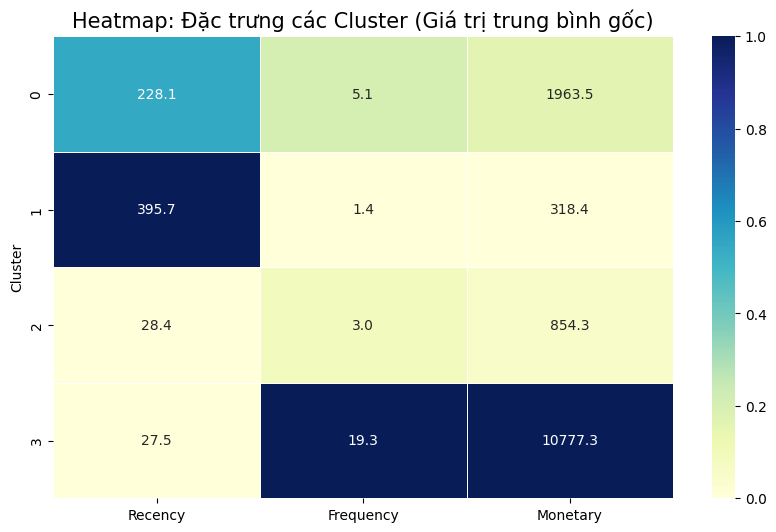

         Recency  Frequency  Monetary              Segment
Cluster                                                   
0          228.1        5.1    1963.5              At Risk
1          395.7        1.4     318.4       Lost Customers
2           28.4        3.0     854.3  Potential Loyalists
3           27.5       19.3   10777.3      Champions (VIP)


In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tính giá trị trung bình gốc để hiển thị (bảng tóm tắt)
cluster_profile_raw = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(1)

# 2. Chuẩn hóa lại bảng này để vẽ Heatmap (giúp màu sắc phản ánh đúng độ cao/thấp)
# Chúng ta dùng MinMaxScaler để các chỉ số về cùng thang [0, 1] cho dễ so sánh màu
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cluster_profile_scaled = scaler.fit_transform(cluster_profile_raw)
cluster_profile_scaled = pd.DataFrame(cluster_profile_scaled,
                                     index=cluster_profile_raw.index,
                                     columns=cluster_profile_raw.columns)

# 3. Vẽ Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile_scaled, annot=cluster_profile_raw, fmt=".1f", cmap='YlGnBu', linewidths=.5)
plt.title('Heatmap: Đặc trưng các Cluster (Giá trị trung bình gốc)', fontsize=15)
plt.ylabel('Cluster')
plt.show()

# In bảng tóm tắt kèm theo nhãn bạn đã đặt
cluster_profile_raw['Segment'] = cluster_profile_raw.index.map(cluster_map)
print(cluster_profile_raw)

In [50]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

# 1. Khởi tạo và fit mô hình Agglomerative với cùng k=4
agg_model = AgglomerativeClustering(n_clusters=4)
agg_labels = agg_model.fit_predict(rfm_scaled)

# 2. Tính Silhouette Score cho cả 2 phương pháp để so sánh
# Lưu ý: rfm['Cluster'] là nhãn từ KMeans bạn đã làm ở Cell 16
kmeans_score = silhouette_score(rfm_scaled, rfm['Cluster'])
agg_score = silhouette_score(rfm_scaled, agg_labels)

# 3. In kết quả
print(f"Silhouette Score của K-Means: {kmeans_score:.4f}")
print(f"Silhouette Score của Agglomerative Clustering: {agg_score:.4f}")

# 4. Kiểm tra sự phân bổ số lượng khách hàng của Agglomerative
import pandas as pd
print("\nPhân bổ khách hàng của Agglomerative:")
print(pd.Series(agg_labels).value_counts())

Silhouette Score của K-Means: 0.3647
Silhouette Score của Agglomerative Clustering: 0.3092

Phân bổ khách hàng của Agglomerative:
0    1692
2    1632
1    1350
3    1207
Name: count, dtype: int64


## Agglomerative

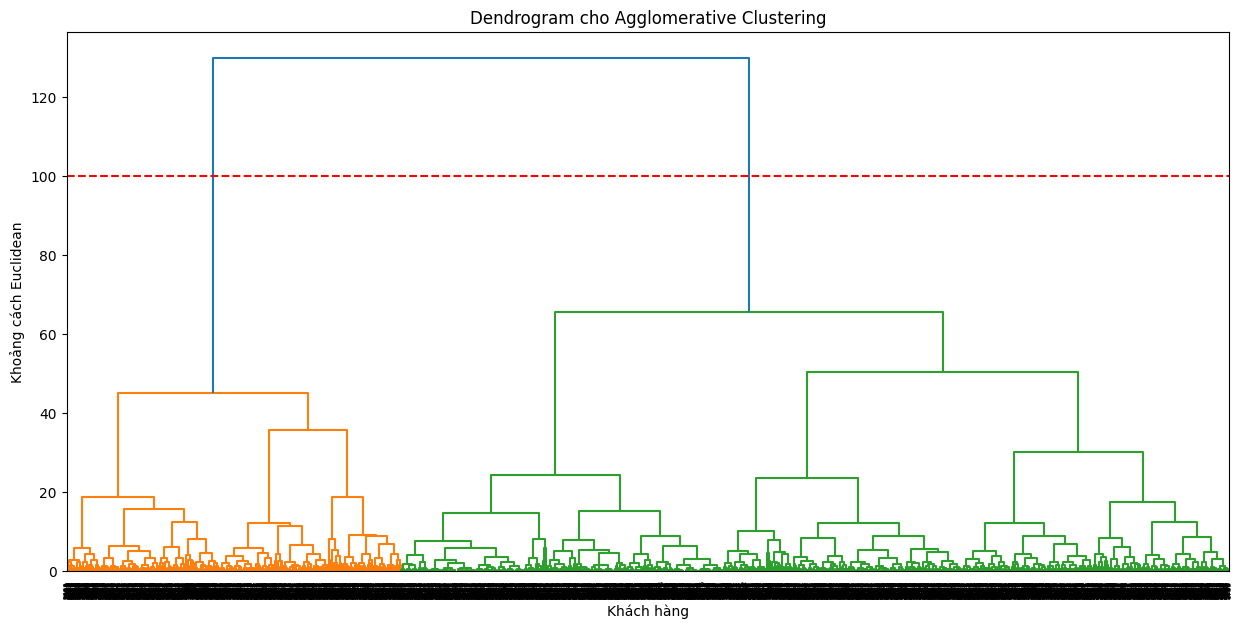

In [51]:
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(15, 7))
# Vẽ dendrogram trên dữ liệu scaled
dendrogram = sch.dendrogram(sch.linkage(rfm_scaled, method='ward'))
plt.title('Dendrogram cho Agglomerative Clustering')
plt.xlabel('Khách hàng')
plt.ylabel('Khoảng cách Euclidean')
plt.axhline(y=100, color='r', linestyle='--') # Đường cắt giả định để ra k cụm
plt.show()

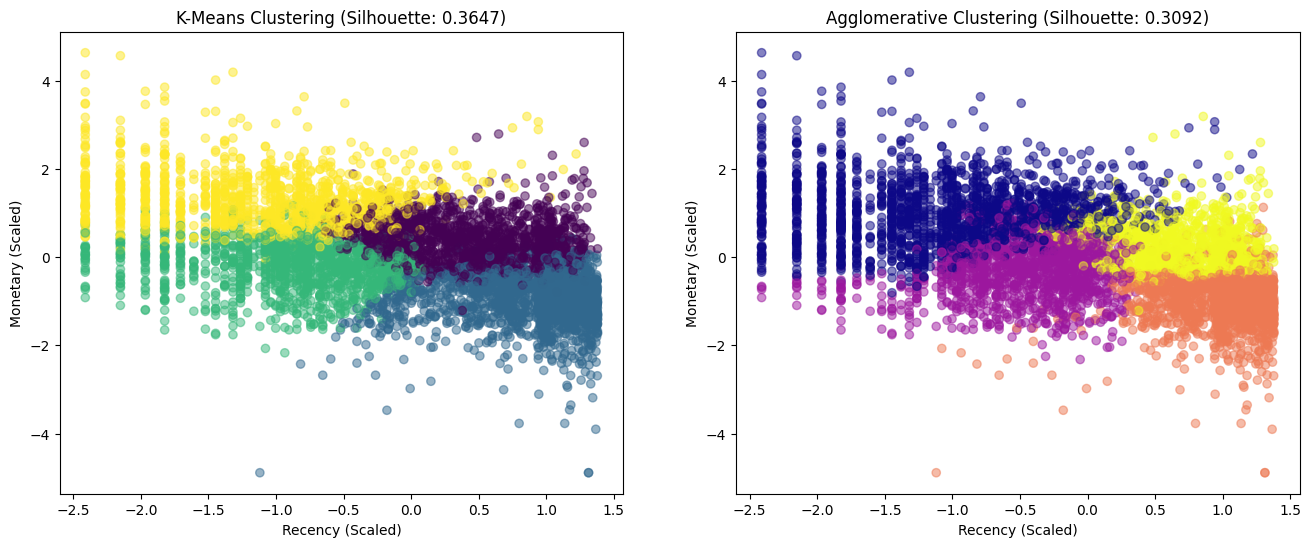

In [52]:
import matplotlib.pyplot as plt

# Đảm bảo rfm_scaled là numpy array để dùng được cú pháp [:, 0]
# Nếu rfm_scaled của bạn đã là array từ bước chuẩn hóa thì không sao,
# nhưng nếu là DataFrame thì phải dùng .values
X = rfm_scaled.values if hasattr(rfm_scaled, 'columns') else rfm_scaled

plt.figure(figsize=(16, 6))

# Bên trái: K-Means
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 2], c=rfm['Cluster'], cmap='viridis', alpha=0.5)
plt.title(f'K-Means Clustering (Silhouette: {kmeans_score:.4f})')
plt.xlabel('Recency (Scaled)')
plt.ylabel('Monetary (Scaled)')

# Bên phải: Agglomerative
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 2], c=agg_labels, cmap='plasma', alpha=0.5)
plt.title(f'Agglomerative Clustering (Silhouette: {agg_score:.4f})')
plt.xlabel('Recency (Scaled)')
plt.ylabel('Monetary (Scaled)')

plt.show()

## Conclusion 1

**Nhận xét**: Hình ảnh so sánh Scatter Plot cho thấy K-Means tạo ra các phân cụm có cấu trúc chặt chẽ và ranh giới rõ ràng hơn. Kết hợp với chỉ số Silhouette vượt trội ($0.3647$ so với $0.3092$),nhóm chọn định K-Means là lựa chọn tối ưu. Thuật toán này giúp tách biệt rõ rệt nhóm khách hàng có chi tiêu cao (Monetary) và mới mua hàng (Recency), phục vụ tốt cho việc xây dựng chiến lược Marketing cá nhân hóa."

# RQ2
Các đặc trưng hành vi RFM có thể dự đoán phân khúc giá trị của một khách hàng với độ chính xác đủ cao không, và thuật toán nào cho hiệu suất tốt nhất?

Sau khi các phân khúc khách hàng được xác định từ RQ1, nghiên cứu tiếp tục xây dựng các mô hình học máy nhằm tự động dự đoán khách hàng thuộc phân khúc nào dựa trên các đặc trưng hành vi của họ. Các thuật toán phân loại như Logistic Regression, Decision Tree và Random Forest sẽ được huấn luyện và đánh giá thông qua nhiều chỉ số như Accuracy, Precision, Recall và F1-score. Việc so sánh hiệu suất giữa các mô hình giúp xác định thuật toán phù hợp nhất cho bài toán phân loại khách hàng trong thực tế. Đồng thời, nghiên cứu cũng phân tích mức độ ảnh hưởng của từng biến đầu vào nhằm xác định yếu tố nào đóng vai trò quan trọng nhất trong việc hình thành giá trị khách hàng, từ đó hỗ trợ doanh nghiệp triển khai các chiến lược CRM và marketing hiệu quả hơn.


## Data Preparation

In [53]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [54]:

# Chúng ta tính RFM và kèm theo Unique Products
unique_prod_df = df.groupby('Customer ID')['StockCode'].nunique().reset_index()
unique_prod_df.columns = ['Customer ID', 'UniqueProducts']

# Sau đó bạn merge nó vào bảng rfm của mình
rfm = rfm.merge(unique_prod_df, on='Customer ID')

In [55]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Chuẩn bị Feature (X) và Target (y)
# Loại bỏ CancellationRate khỏi danh sách
features = ['Recency', 'Frequency', 'Monetary', 'UniqueProducts']
X = rfm[features]
y = rfm['Cluster']

# 2. Thực hiện Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y # Để giữ tỷ lệ các nhóm VIP/Lost
)

# 3. Kiểm tra kết quả
print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")

print("\n--- Tỷ lệ các nhóm trong tập Train và Test ---")
train_dist = y_train.value_counts(normalize=True).sort_index()
test_dist = y_test.value_counts(normalize=True).sort_index()
print(pd.DataFrame({'Train (%)': train_dist, 'Test (%)': test_dist}) * 100)

Kích thước X_train: (4704, 4)
Kích thước X_test: (1177, 4)

--- Tỷ lệ các nhóm trong tập Train và Test ---
         Train (%)   Test (%)
Cluster                      
0        24.872449  24.893798
1        33.652211  33.644860
2        21.279762  21.240442
3        20.195578  20.220901


## Logistic Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       293
           1       0.95      0.93      0.94       396
           2       0.90      0.88      0.89       250
           3       0.92      0.97      0.94       238

    accuracy                           0.91      1177
   macro avg       0.91      0.91      0.91      1177
weighted avg       0.91      0.91      0.91      1177



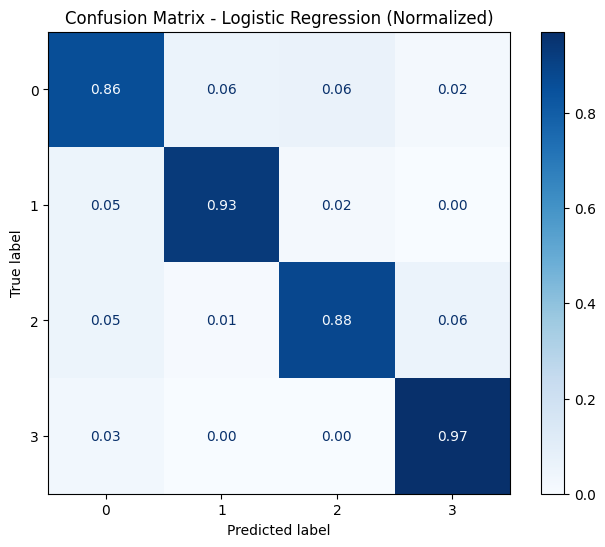

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Khởi tạo và huấn luyện mô hình
# Tăng max_iter lên 1000 để đảm bảo mô hình hội tụ (vì dữ liệu RFM có thể chênh lệch lớn)
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# 2. Dự đoán trên tập Test
y_pred_log = log_reg.predict(X_test)

# 3. Xuất kết quả báo cáo
print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_log))

# 4. Vẽ Confusion Matrix (Ma trận nhầm lẫn)
fig, ax = plt.subplots(figsize=(8, 6))
# Normalize='true' để xem tỉ lệ % dự đoán đúng trên từng class
cm = confusion_matrix(y_test, y_pred_log, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_reg.classes_)
disp.plot(cmap='Blues', ax=ax, values_format='.2f')

plt.title('Confusion Matrix - Logistic Regression (Normalized)')
plt.show()

**Nhận xét**: Hầu như là ở các cụm, mô hình học khá tốt:
- Cluster 3 (Champions - VIP): Có F1-score lên tới 0.94 và Recall tận 0.97. Nghĩa là mô hình gần như không bỏ sót một khách hàng VIP nào.
- Cluster 2 (Loyal Customer): Cũng ghi nhận mức khá cao là 0.88. Như vậy thì mô hình cũng bắt được đa số các khách hàng trung thành

- Cluster 1 (Lost Customers): Cũng đạt F1-score 0.93. Nhóm này có đặc điểm rất rõ rệt vì Recency cao nên máy nhận diện dễ dàng.

- Cluster 0 (At Risk): Có điểm thấp nhất (0.86) nhưng vẫn là con số rất cao. Sự nhầm lẫn nhẹ ở đây thường là giữa nhóm "Sắp mất" và "Đã mất" vì ranh giới về số ngày không mua hàng giữa hai nhóm này thường khá mỏng.



## Decision Tree

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.86      0.90       293
           1       0.93      0.96      0.95       396
           2       0.88      0.98      0.93       250
           3       0.99      0.92      0.95       238

    accuracy                           0.93      1177
   macro avg       0.93      0.93      0.93      1177
weighted avg       0.93      0.93      0.93      1177



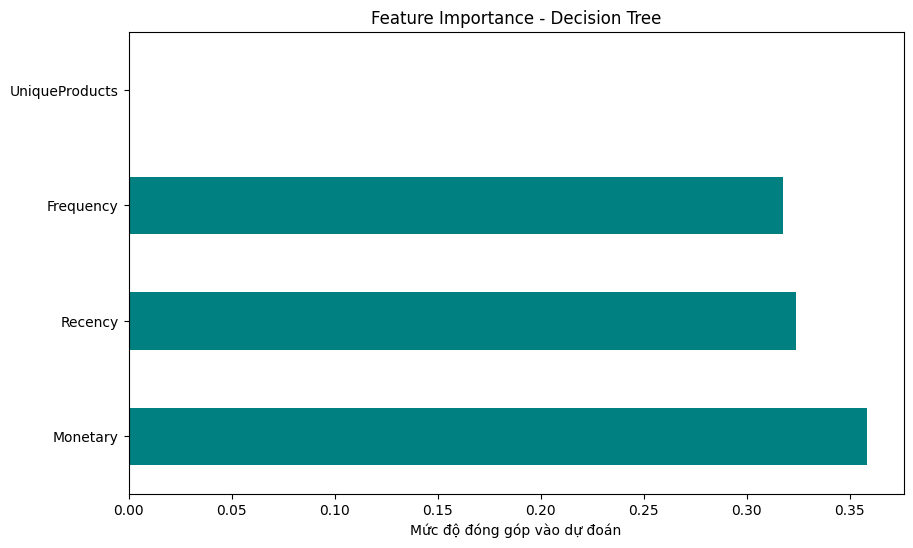

In [57]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix

# 1. Khởi tạo mô hình. Chúng ta giới hạn max_depth để cây không bị quá sâu (overfitting)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

# 2. Dự đoán
y_pred_dt = dt_model.predict(X_test)

# 3. Xuất kết quả
print("--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred_dt))

# 4. Vẽ Feature Importance
plt.figure(figsize=(10, 6))
feat_importances = pd.Series(dt_model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Feature Importance - Decision Tree')
plt.xlabel('Mức độ đóng góp vào dự đoán')
plt.show()

**Nhận xét**:
- Con số 0.93 (93%) là cao hơn so với mức 0.91 của Logistic Regression. Điều này chứng tỏ các phân cụm của bạn không chỉ phân tách bằng các đường thẳng đơn giản mà có các threshold cắt rõ ràng hơn cắt rất rõ ràng.
- Ngoài ra, nhìn vào biểu đồ ta thấy Mọnetary là biến đóng góp nhiều nhất vào việc phân loại của mô hình, trong khi đó Moneytary và Recency thì khá đồng đều trong việc phân loại

## Random Forest

Thông số tốt nhất tìm được: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 100}

--- Random Forest Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       293
           1       0.99      0.99      0.99       396
           2       0.95      0.99      0.97       250
           3       0.98      0.96      0.97       238

    accuracy                           0.98      1177
   macro avg       0.98      0.98      0.98      1177
weighted avg       0.98      0.98      0.98      1177



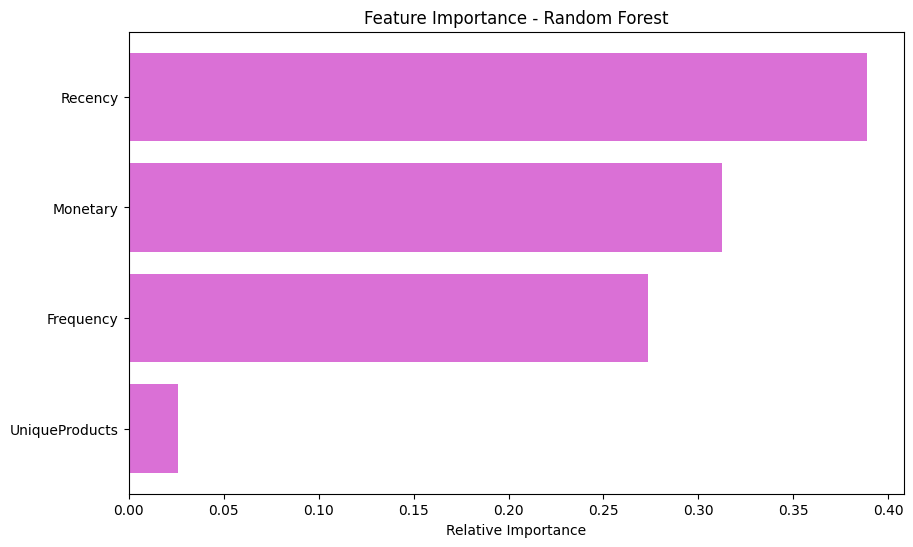

In [58]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np

# 1. Thiết lập dải thông số để máy tự đi tìm bộ thông số tốt nhất (Tuning)
param_grid = {
    'n_estimators': [100, 200], # Số lượng cây trong rừng
    'max_depth': [5, 8, 12],     # Độ sâu tối đa của mỗi cây
    'min_samples_split': [2, 5], # Số lượng mẫu tối thiểu để tách nhánh
    'criterion': ['gini', 'entropy']
}

# 2. Khởi tạo mô hình và dùng GridSearchCV để "thử sai"
rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid,
                           cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

# 3. Lấy ra mô hình tốt nhất
best_rf = grid_search.best_estimator_
y_pred_rf = best_rf.predict(X_test)

# 4. In kết quả thông số tốt nhất và Báo cáo phân loại
print(f"Thông số tốt nhất tìm được: {grid_search.best_params_}")
print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf))

# 5. Vẽ Feature Importance
importances = best_rf.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importance - Random Forest')
plt.barh(range(len(indices)), importances[indices], color='orchid', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

**Nhận xét**:
- Mô hình cho kết quả tốt với độ chính xác (0.98) - Đây là mức điểm gần như tuyệt đối. Sự nhầm lẫn giữa các nhóm giờ đây chỉ còn khoảng 2%.

Bên cạnh đó:

- Recency (Số ngày không mua hàng): Đóng vai trò quan trọng nhất. Điều này hợp lý vì trong bán lẻ, thời gian vắng mặt là dấu hiệu rõ nhất để phân biệt khách rời bỏ và khách trung thành.

- Monetary & Frequency: Đứng thứ 2 và 3 với mức độ đóng góp khá cân bằng.

- UniqueProducts: Có vẻ như chỉ số này đóng góp rất ít.

## Model Comparison

,Model,Accuracy,F1-Macro
0,Logistic Regression,0.91,0.91
1,Decision Tree,0.93,0.93
2,Random Forest,0.98,0.98


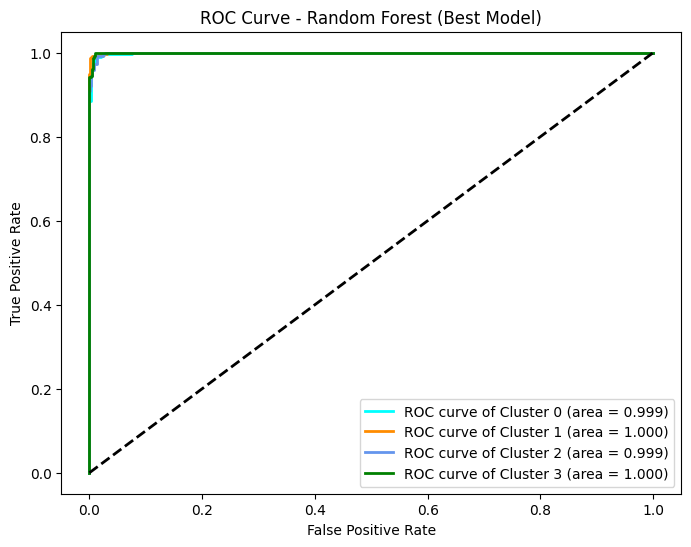

In [59]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import pandas as pd

# 1. Tạo bảng so sánh các chỉ số (Sử dụng kết quả bạn đã chạy)
comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.91, 0.93, 0.98],
    'F1-Macro': [0.91, 0.93, 0.98] # Bạn có thể cập nhật số chính xác từ report của mình
}
comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# 2. Vẽ ROC Curve cho Random Forest (Mô hình tốt nhất)
# Vì đây là đa lớp, chúng ta sẽ binarize nhãn để vẽ
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])
n_classes = y_test_bin.shape[1]
y_score = best_rf.predict_proba(X_test)

plt.figure(figsize=(8, 6))
colors = ['aqua', 'darkorange', 'cornflowerblue', 'green']
for i, color in zip(range(n_classes), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC curve of Cluster {i} (area = {roc_auc:0.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest (Best Model)')
plt.legend(loc="lower right")
plt.show()

**Nhận xét** : Kết quả cho thấy Random Forest đạt hiệu năng cao nhất với Accuracy và F1-Macro đều đạt 0.98, vượt trội hơn so với Decision Tree và Logistic Regression. Điều này cho thấy ensemble learning giúp mô hình học được các pattern phức tạp trong dữ liệu hiệu quả hơn. Logistic Regression tuy đơn giản hơn nhưng vẫn đạt kết quả tốt với độ chính xác 91%, cho thấy dữ liệu vẫn có khả năng phân tách tương đối rõ ràng.

## Cross Validation

In [60]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. Thiết lập K-Fold (5 lần chia dữ liệu)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Tính toán điểm số trên từng Fold
cv_scores = cross_val_score(best_rf, X, y, cv=skf, scoring='accuracy')

# 3. Xuất kết quả
print(f"Scores qua 5 lần chạy: {cv_scores}")
print(f"Accuracy trung bình: {cv_scores.mean():.4f}")
print(f"Độ lệch chuẩn (Std): {cv_scores.std():.4f}")

if cv_scores.std() < 0.02:
    print("\n=> Nhận xét: Độ lệch chuẩn thấp. Mô hình hoạt động ổn định trên toàn bộ dữ liệu")

Scores qua 5 lần chạy: [0.97706032 0.97704082 0.98554422 0.97704082 0.98129252]
Accuracy trung bình: 0.9796
Độ lệch chuẩn (Std): 0.0034

=> Nhận xét: Độ lệch chuẩn thấp. Mô hình hoạt động ổn định trên toàn bộ dữ liệu


## Conclusion 2

**Kết luận**: Random Forest được lựa chọn là mô hình dự báo cuối cùng nhờ đạt độ chính xác vượt trội (98%), cao hơn hẳn so với Logistic Regression (91%) và Decision Tree (93%). Mô hình thể hiện khả năng phân loại gần như hoàn hảo ở tất cả các nhóm khách hàng, đặc biệt là khả năng xử lý tốt các vùng dữ liệu giao thoa phức tạp mà các mô hình đơn lẻ thường mắc lỗi. Kết quả Cross-Validation với độ lệch chuẩn siêu thấp (0.0034) là minh chứng cho tính ổn định tuyệt đối, khẳng định đây là công cụ đáng tin cậy để doanh nghiệp tự động hóa việc phân loại và đưa ra các chiến lược chăm sóc khách hàng chính xác trong tương lai.

# RQ3
Hành vi quay lại mua hàng giữa các phân khúc khách
hàng thay đổi như thế nào theo thời gian trong các cohort khách hàng khác nhau, và thời điểm nào xảy ra churn nhiều nhất?

Bên cạnh việc phân tích hành vi khách hàng tại một thời điểm cố định, nghiên cứu tiếp tục xem xét sự thay đổi của tỷ lệ giữ chân khách hàng theo thời gian có khác nhau giữa các phân khú hay không thông qua phương pháp Cohort Retention Analysis. Các khách hàng sẽ được nhóm theo thời điểm mua hàng đầu tiên để theo dõi mức độ quay lại mua hàng qua từng giai đoạn. Từ đó, nghiên cứu xây dựng ma trận retention nhằm quan sát xu hướng suy giảm số lượng khách hàng theo thời gian và xác định giai đoạn xảy ra mức sụt giảm mạnh nhất. Ngoài ra, nghiên cứu cũng thực hiện kiểm định thống kê để đánh giá liệu sự khác biệt về tỷ lệ giữ chân khách hàng giữa các cohort theo thời gian có mang ý nghĩa thống kê hay không. Kết quả thu được giúp doanh nghiệp nhận diện giai đoạn nhạy cảm trong vòng đời khách hàng và đưa ra chiến lược giữ chân phù hợp hơn.


In [61]:
import datetime as dt

Bộ dataset bao gồm 3 năm từ 2009 đế 2011, tuy nhiên để thuận tiện trong việc phân tích và phù hợp với việc xem xét hành vi khách hàng trong tương lai thì nhóm tiến hành sử dụng năm gần nhất là 2011

In [62]:
df_11 = df[df['InvoiceDate'].dt.year == 2011].copy()

In [63]:
df_11

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,revenue
567942,539993,22386,JUMBO BAG PINK POLKADOT,10,2011-01-04 10:00:00,1.95,13313.0,United Kingdom,19.50
567943,539993,21499,BLUE POLKADOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,10.50
567944,539993,21498,RED RETROSPOT WRAP,25,2011-01-04 10:00:00,0.42,13313.0,United Kingdom,10.50
567945,539993,22379,RECYCLING BAG RETROSPOT,5,2011-01-04 10:00:00,2.10,13313.0,United Kingdom,10.50
567946,539993,20718,RED RETROSPOT SHOPPER BAG,10,2011-01-04 10:00:00,1.25,13313.0,United Kingdom,12.50
...,...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85


## Cohort Analysis

Tính cho toàn bộ phân khúc khách hàng

In [64]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [65]:
import datetime as dt
from operator import attrgetter
import matplotlib.colors as mcolors
import seaborn as sns

In [66]:
#b1: tính cohort cho toàn bộ tệp khách hàng

In [67]:
df_total = df_11.copy()

In [68]:
#Tính toán các công thức cần thiết
df_total['first_month']= df_11.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
df_total['current_month'] = df_11['InvoiceDate'].dt.to_period('M')
df_total['subsequent_month'] = (df_total['current_month'] - df_total['first_month']).apply(attrgetter('n'))

In [69]:
df_total['Customer ID'].is_unique

False

In [70]:
#group by cohort
df_total_cohort = df_total.groupby(['first_month','current_month','subsequent_month']).agg(
    n_customer = ('Customer ID','nunique')
).reset_index()

In [71]:
df_total_cohort

,first_month,current_month,subsequent_month,n_customer
0,2011-01,2011-01,0,741
1,2011-01,2011-02,1,262
2,2011-01,2011-03,2,319
3,2011-01,2011-04,3,284
4,2011-01,2011-05,4,339
...,...,...,...,...
73,2011-10,2011-11,1,91
74,2011-10,2011-12,2,42
75,2011-11,2011-11,0,361
76,2011-11,2011-12,1,38


In [72]:
df_total_pivot = df_total_cohort.pivot_table(index='first_month',columns = 'subsequent_month',values='n_customer')

In [73]:
df_total_pivot

subsequent_month,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2011-01,741.0,262.0,319.0,284.0,339.0,311.0,290.0,285.0,325.0,309.0,381.0,190.0
2011-02,496.0,116.0,123.0,169.0,155.0,135.0,151.0,163.0,153.0,181.0,61.0,NaN
2011-03,539.0,88.0,144.0,120.0,123.0,101.0,153.0,130.0,162.0,57.0,NaN,NaN
2011-04,361.0,85.0,79.0,85.0,76.0,85.0,88.0,107.0,31.0,NaN,NaN,NaN
2011-05,319.0,58.0,56.0,58.0,70.0,77.0,88.0,31.0,NaN,NaN,NaN,NaN
2011-06,268.0,47.0,41.0,68.0,60.0,91.0,26.0,NaN,NaN,NaN,NaN,NaN
2011-07,213.0,38.0,47.0,49.0,57.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,185.0,39.0,47.0,46.0,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-09,316.0,76.0,100.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [74]:
#chuyển về %
cohort_size_total = df_total_pivot.iloc[:,0]
retention_matrix_total = df_total_pivot.divide(cohort_size_total,axis=0)

In [75]:
retention_matrix_total

subsequent_month,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2011-01,1.0,0.353576,0.430499,0.383266,0.457490,0.419703,0.391363,0.384615,0.438596,0.417004,0.514170,0.25641
2011-02,1.0,0.233871,0.247984,0.340726,0.312500,0.272177,0.304435,0.328629,0.308468,0.364919,0.122984,NaN
2011-03,1.0,0.163265,0.267161,0.222635,0.228200,0.187384,0.283859,0.241187,0.300557,0.105751,NaN,NaN
2011-04,1.0,0.235457,0.218837,0.235457,0.210526,0.235457,0.243767,0.296399,0.085873,NaN,NaN,NaN
2011-05,1.0,0.181818,0.175549,0.181818,0.219436,0.241379,0.275862,0.097179,NaN,NaN,NaN,NaN
2011-06,1.0,0.175373,0.152985,0.253731,0.223881,0.339552,0.097015,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.178404,0.220657,0.230047,0.267606,0.136150,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.210811,0.254054,0.248649,0.135135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-09,1.0,0.240506,0.316456,0.123418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Retention Matrix (in %):
subsequent_month      0     1     2     3     4     5     6     7     8     9  \
first_month                                                                     
2011-01           100.0  35.4  43.0  38.3  45.7  42.0  39.1  38.5  43.9  41.7   
2011-02           100.0  23.4  24.8  34.1  31.2  27.2  30.4  32.9  30.8  36.5   
2011-03           100.0  16.3  26.7  22.3  22.8  18.7  28.4  24.1  30.1  10.6   
2011-04           100.0  23.5  21.9  23.5  21.1  23.5  24.4  29.6   8.6   NaN   
2011-05           100.0  18.2  17.6  18.2  21.9  24.1  27.6   9.7   NaN   NaN   
2011-06           100.0  17.5  15.3  25.4  22.4  34.0   9.7   NaN   NaN   NaN   
2011-07           100.0  17.8  22.1  23.0  26.8  13.6   NaN   NaN   NaN   NaN   
2011-08           100.0  21.1  25.4  24.9  13.5   NaN   NaN   NaN   NaN   NaN   
2011-09           100.0  24.1  31.6  12.3   NaN   NaN   NaN   NaN   NaN   NaN   
2011-10           100.0  24.3  11.2   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
201

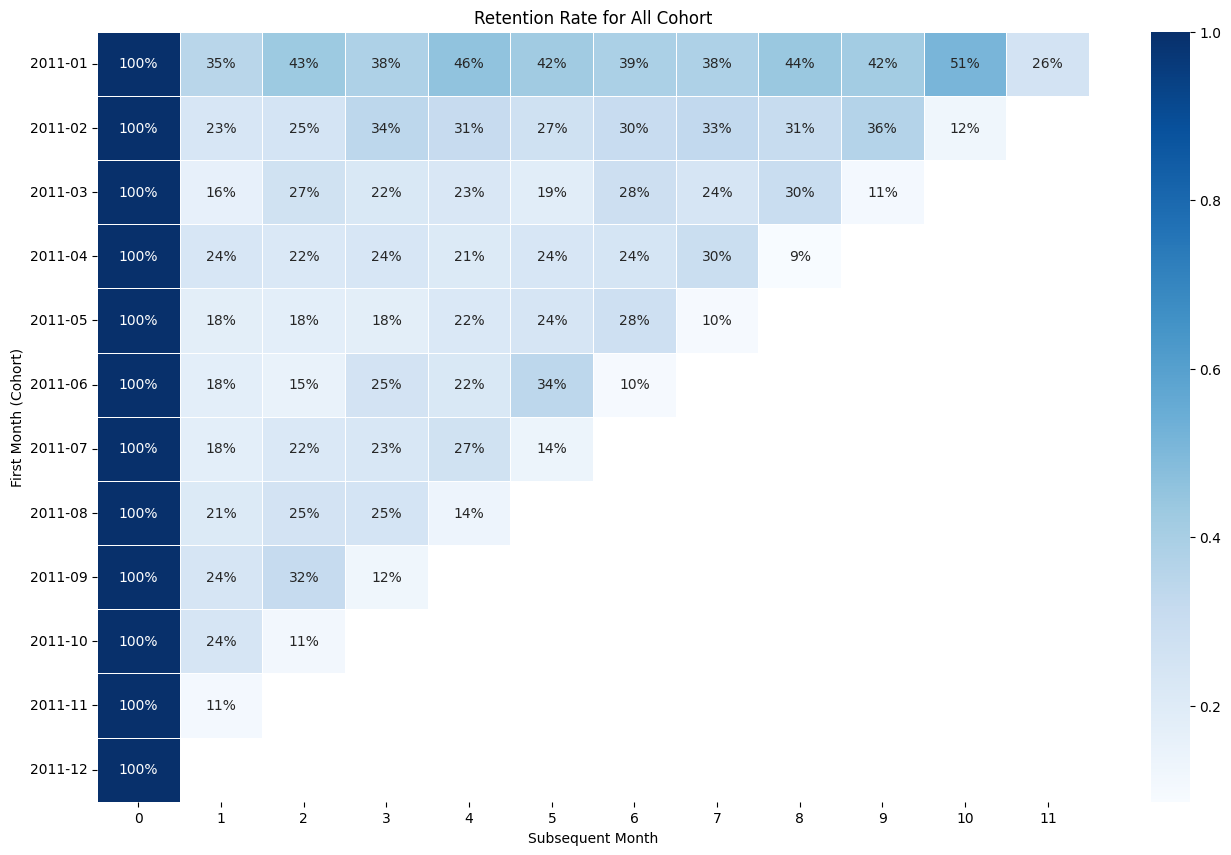

In [76]:
# Định dạng lại index và columns để hiển thị đẹp hơn trên heatmap
retention_matrix_total.index = retention_matrix_total.index.astype(str)
retention_matrix_total.columns = retention_matrix_total.columns.astype(str)

print("Retention Matrix (in %):")
print(retention_matrix_total.round(3) * 100)

# Trực quan hóa ma trận giữ chân khách hàng bằng heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(retention_matrix_total, annot=True, fmt='.0%', cmap='Blues', linewidths=0.5, linecolor='white')
plt.title('Retention Rate for All Cohort')
plt.xlabel('Subsequent Month')
plt.ylabel('First Month (Cohort)')
plt.yticks(rotation=0)
plt.show()

In [77]:
rfm

,Customer ID,Recency,Frequency,Monetary,Cluster,Segment,UniqueProducts
0,12346.0,326,12,77556.46,3,Champions (VIP),27
1,12347.0,2,8,4921.53,3,Champions (VIP),126
2,12348.0,75,5,2019.40,0,At Risk,25
3,12349.0,19,4,4428.69,2,Potential Loyalists,138
4,12350.0,310,1,334.40,1,Lost Customers,17
...,...,...,...,...,...,...,...
5876,18283.0,4,22,2664.90,3,Champions (VIP),352
5877,18284.0,432,1,461.68,1,Lost Customers,28
5878,18285.0,661,1,427.00,1,Lost Customers,12
5879,18286.0,477,2,1296.43,0,At Risk,67


##VIP Customer

In [78]:
rfm_join = pd.merge(df,rfm,on ='Customer ID', how = 'left')

In [79]:
rfm_11 = rfm_join[rfm_join['InvoiceDate'].dt.year== 2011]

In [80]:
rfm_11['Segment'].unique()

array(['Champions (VIP)', 'At Risk', 'Lost Customers',
       'Potential Loyalists'], dtype=object)

In [81]:
df_vip = rfm_11[rfm_11['Segment'] == 'Champions (VIP)']

In [82]:
df_vip['first_month'] = df_vip.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
df_vip['current_month'] = df_vip['InvoiceDate'].dt.to_period('M')
df_vip['subsequent_month'] = (df_vip['current_month'] - df_vip['first_month']).apply(attrgetter('n'))

/tmp/ipykernel_1400/2516433692.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vip['first_month'] = df_vip.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
/tmp/ipykernel_1400/2516433692.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vip['current_month'] = df_vip['InvoiceDate'].dt.to_period('M')
/tmp/ipykernel_1400/2516433692.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value

In [83]:
#group by cohort
df_vip_cohort = df_vip.groupby(['first_month','current_month','subsequent_month']).agg(
    n_customer = ('Customer ID','nunique')
).reset_index()

In [84]:
df_vip_pivot = df_vip_cohort.pivot_table(index = 'first_month',columns='subsequent_month',values='n_customer')

In [85]:
df_vip_pivot

subsequent_month,0,1,2,3,4,5,6,7,8,9,10,11
first_month,,,,,,,,,,,,
2011-01,463.0,228.0,284.0,244.0,289.0,274.0,257.0,253.0,286.0,275.0,348.0,185.0
2011-02,221.0,83.0,95.0,124.0,108.0,99.0,114.0,124.0,118.0,151.0,55.0,NaN
2011-03,180.0,54.0,83.0,77.0,74.0,71.0,93.0,82.0,122.0,46.0,NaN,NaN
2011-04,91.0,43.0,37.0,42.0,44.0,39.0,54.0,61.0,18.0,NaN,NaN,NaN
2011-05,63.0,19.0,23.0,28.0,29.0,29.0,41.0,23.0,NaN,NaN,NaN,NaN
2011-06,55.0,18.0,16.0,35.0,24.0,43.0,16.0,NaN,NaN,NaN,NaN,NaN
2011-07,23.0,7.0,13.0,14.0,15.0,13.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,17.0,7.0,9.0,10.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-09,31.0,18.0,25.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
#chuyển sang %
cohort_size_vip = df_vip_pivot.iloc[:,0]
retention_matrix_vip = df_vip_pivot.divide(cohort_size_vip,axis=0)

Retention Matrix (in %):
subsequent_month      0     1     2     3     4     5     6     7     8     9  \
first_month                                                                     
2011-01           100.0  49.2  61.3  52.7  62.4  59.2  55.5  54.6  61.8  59.4   
2011-02           100.0  37.6  43.0  56.1  48.9  44.8  51.6  56.1  53.4  68.3   
2011-03           100.0  30.0  46.1  42.8  41.1  39.4  51.7  45.6  67.8  25.6   
2011-04           100.0  47.3  40.7  46.2  48.4  42.9  59.3  67.0  19.8   NaN   
2011-05           100.0  30.2  36.5  44.4  46.0  46.0  65.1  36.5   NaN   NaN   
2011-06           100.0  32.7  29.1  63.6  43.6  78.2  29.1   NaN   NaN   NaN   
2011-07           100.0  30.4  56.5  60.9  65.2  56.5   NaN   NaN   NaN   NaN   
2011-08           100.0  41.2  52.9  58.8  47.1   NaN   NaN   NaN   NaN   NaN   
2011-09           100.0  58.1  80.6  54.8   NaN   NaN   NaN   NaN   NaN   NaN   
2011-10           100.0  63.2  36.8   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
201

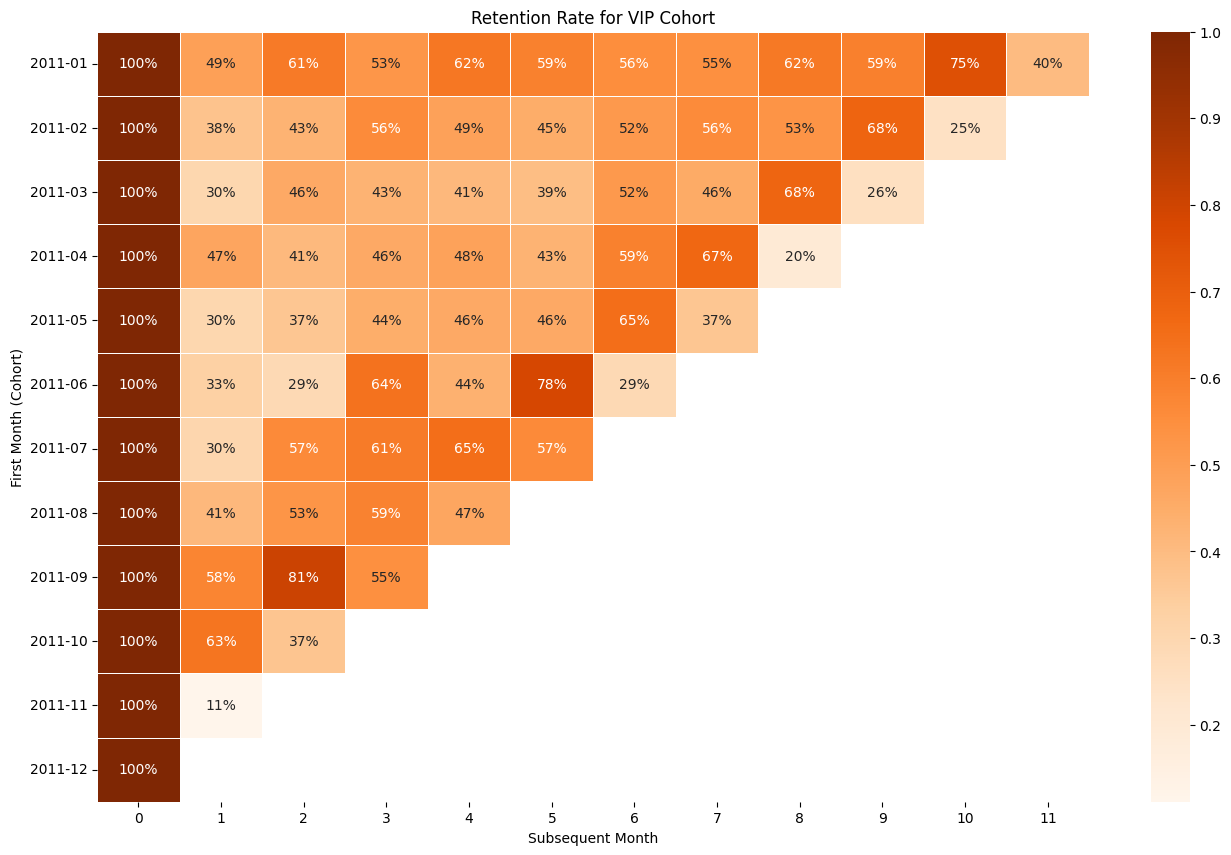

In [87]:
# Định dạng lại index và columns để hiển thị đẹp hơn trên heatmap
retention_matrix_vip.index = retention_matrix_vip.index.astype(str)
retention_matrix_vip.columns = retention_matrix_vip.columns.astype(str)

print("Retention Matrix (in %):")
print(retention_matrix_vip.round(3) * 100)

# Trực quan hóa ma trận giữ chân khách hàng (Retention Matrix) bằng heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(retention_matrix_vip, annot=True, fmt='.0%', cmap='Oranges', linewidths=0.5, linecolor='white')
plt.title('Retention Rate for VIP Cohort')
plt.xlabel('Subsequent Month')
plt.ylabel('First Month (Cohort)')
plt.yticks(rotation=0)
plt.show()

In [88]:
rfm['Segment'].unique()

array(['Champions (VIP)', 'At Risk', 'Potential Loyalists',
       'Lost Customers'], dtype=object)

## Potential Loyalists

In [89]:
df_loyal = rfm_11[rfm_11['Segment'] == 'Potential Loyalists']

In [90]:
df_loyal['first_month'] = df_loyal.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
df_loyal['current_month'] = df_loyal['InvoiceDate'].dt.to_period('M')
df_loyal['subsequent_month'] = (df_loyal['current_month'] - df_loyal['first_month']).apply(attrgetter('n'))

/tmp/ipykernel_1400/1708305680.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_loyal['first_month'] = df_loyal.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
/tmp/ipykernel_1400/1708305680.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_loyal['current_month'] = df_loyal['InvoiceDate'].dt.to_period('M')
/tmp/ipykernel_1400/1708305680.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer]

In [91]:
#group by cohort
df_loyal_cohort = df_loyal.groupby(['first_month','current_month','subsequent_month']).agg(
    n_customer = ('Customer ID','nunique')
).reset_index()



In [92]:
df_loyal_pivot = df_loyal_cohort.pivot_table(index = 'first_month',columns='subsequent_month',values='n_customer')

In [93]:
cohort_size_loyal = df_loyal_pivot.iloc[:,0]
retention_matrix_loyal = df_loyal_pivot.divide(cohort_size_loyal,axis=0)

Retention Matrix (in %):
subsequent_month      0     1     2     3     4     5     6     7     8     9  \
first_month                                                                     
2011-01           100.0   7.9  15.8  15.8  13.2  13.2  21.1  13.2  10.5  36.8   
2011-02           100.0   7.8   5.9  25.5  21.6  17.6  17.6  15.7  33.3  54.9   
2011-03           100.0  11.3  14.5  14.5  17.7   9.7  17.7  32.3  64.5  17.7   
2011-04           100.0  18.2   9.1  22.7   9.1  31.8  31.8  66.7  19.7   NaN   
2011-05           100.0  17.8  15.1  13.7  23.3  39.7  64.4  11.0   NaN   NaN   
2011-06           100.0  21.2  16.7  31.8  34.8  68.2  15.2   NaN   NaN   NaN   
2011-07           100.0  19.1  30.9  41.2  60.3  23.5   NaN   NaN   NaN   NaN   
2011-08           100.0  32.3  49.2  52.3  26.2   NaN   NaN   NaN   NaN   NaN   
2011-09           100.0  31.5  51.4  15.1   NaN   NaN   NaN   NaN   NaN   NaN   
2011-10           100.0  32.6  14.5   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
201

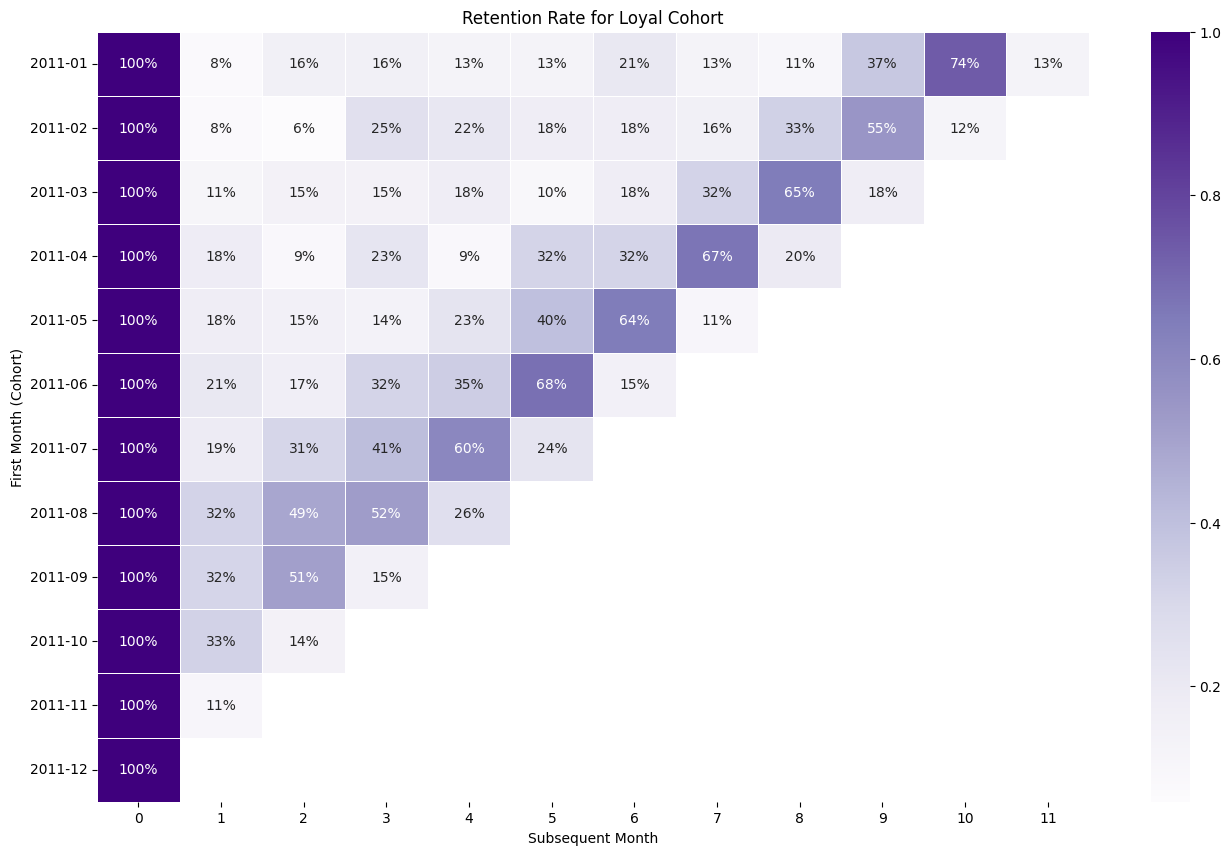

In [94]:
# Định dạng lại index và columns để hiển thị đẹp hơn trên heatmap
retention_matrix_loyal.index = retention_matrix_loyal.index.astype(str)
retention_matrix_loyal.columns = retention_matrix_loyal.columns.astype(str)

print("Retention Matrix (in %):")
print(retention_matrix_loyal.round(3) * 100)

# Trực quan hóa ma trận giữ chân khách hàng (Retention Matrix) bằng heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(retention_matrix_loyal, annot=True, fmt='.0%', cmap='Purples', linewidths=0.5, linecolor='white')
plt.title('Retention Rate for Loyal Cohort')
plt.xlabel('Subsequent Month')
plt.ylabel('First Month (Cohort)')
plt.yticks(rotation=0)
plt.show()

## At Risk

In [95]:
rfm_11['Segment'].unique()

array(['Champions (VIP)', 'At Risk', 'Lost Customers',
       'Potential Loyalists'], dtype=object)

In [96]:
df_risk = rfm_11[rfm_11['Segment'] == 'At Risk']

In [97]:
df_risk['first_month'] = df_risk.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
df_risk['current_month'] = df_risk['InvoiceDate'].dt.to_period('M')
df_risk['subsequent_month'] = (df_risk['current_month'] - df_risk['first_month']).apply(attrgetter('n'))

/tmp/ipykernel_1400/783741156.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_risk['first_month'] = df_risk.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
/tmp/ipykernel_1400/783741156.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_risk['current_month'] = df_risk['InvoiceDate'].dt.to_period('M')
/tmp/ipykernel_1400/783741156.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = valu

In [98]:
#group by cohort
df_risk_cohort = df_risk.groupby(['first_month','current_month','subsequent_month']).agg(
    n_customer = ('Customer ID','nunique')
).reset_index()



In [99]:
df_risk_pivot = df_risk_cohort.pivot_table(index = 'first_month',columns='subsequent_month',values='n_customer')

In [100]:
cohort_size_risk = df_risk_pivot.iloc[:,0]
retention_matrix_risk = df_risk_pivot.divide(cohort_size_risk,axis=0)

Retention Matrix (in %):
subsequent_month      0     1     2     3     4     5     6     7     8     9  \
first_month                                                                     
2011-01           100.0  16.0  16.0  18.3  25.1  17.7  13.1  15.4  19.4  11.4   
2011-02           100.0  15.8  15.8  21.2  23.3  17.1  19.2  21.2  12.3   1.4   
2011-03           100.0  12.2  24.3  15.9  19.6  12.7  23.3  14.8   NaN   NaN   
2011-04           100.0  21.1  25.6  20.3  18.0  18.8   9.8   1.5   NaN   NaN   
2011-05           100.0  18.2  17.3  15.5  20.0  17.3   NaN   NaN   NaN   NaN   
2011-06           100.0  13.2  14.5  15.8  17.1   3.9   NaN   NaN   NaN   NaN   
2011-07           100.0  20.8  16.7   9.7   1.4   NaN   NaN   NaN   NaN   NaN   
2011-08           100.0  16.3  12.2   4.1   NaN   NaN   NaN   NaN   NaN   NaN   
2011-09           100.0  19.4   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2011-10           100.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
201

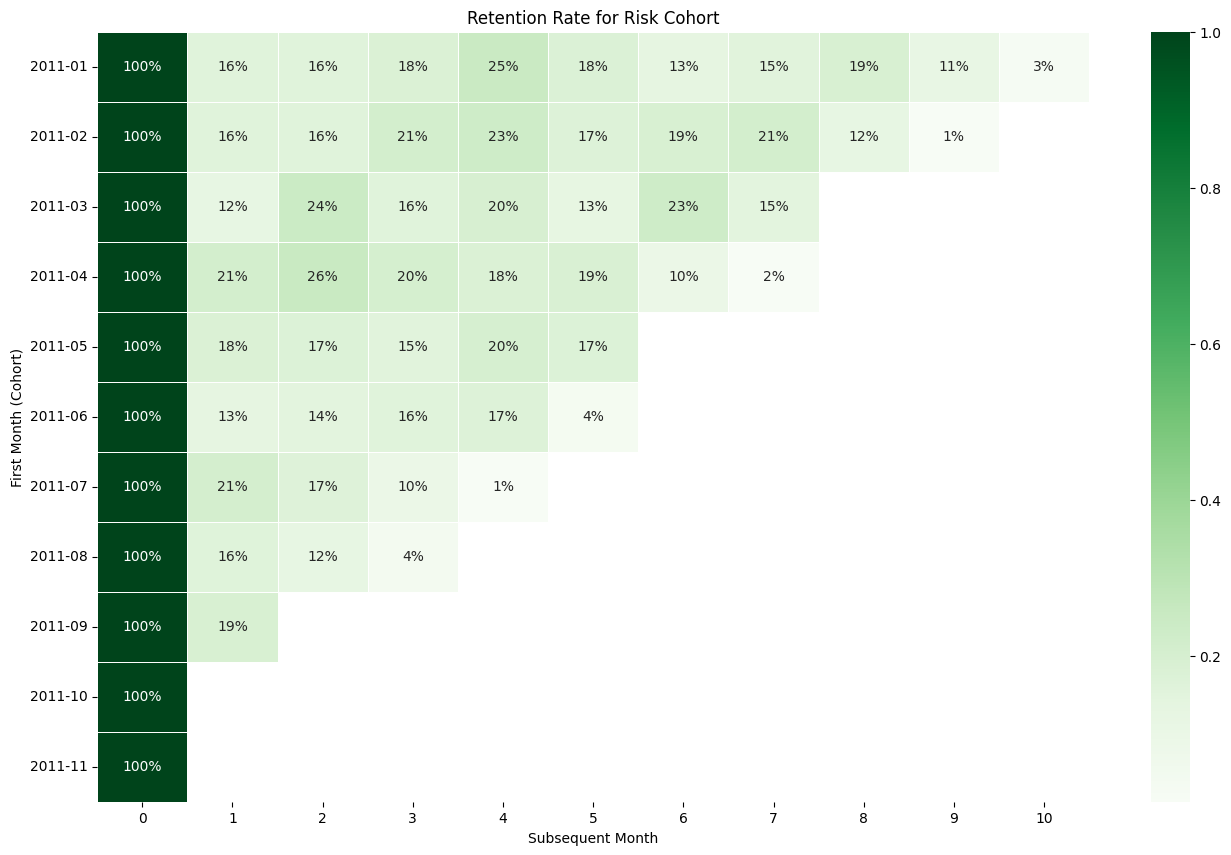

In [101]:
# Định dạng lại index và columns để hiển thị đẹp hơn trên heatmap
retention_matrix_risk.index = retention_matrix_risk.index.astype(str)
retention_matrix_risk.columns = retention_matrix_risk.columns.astype(str)

print("Retention Matrix (in %):")
print(retention_matrix_risk.round(3) * 100)

# Trực quan hóa ma trận giữ chân khách hàng (Retention Matrix) bằng heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(retention_matrix_risk, annot=True, fmt='.0%', cmap='Greens', linewidths=0.5, linecolor='white')
plt.title('Retention Rate for Risk Cohort')
plt.xlabel('Subsequent Month')
plt.ylabel('First Month (Cohort)')
plt.yticks(rotation=0)
plt.show()

## Lost Customer

In [102]:
df_lost = rfm_11[rfm_11['Segment'] == 'Lost Customers']

In [103]:
df_lost['first_month'] = df_lost.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
df_lost['current_month'] = df_lost['InvoiceDate'].dt.to_period('M')
df_lost['subsequent_month'] = (df_lost['current_month'] - df_lost['first_month']).apply(attrgetter('n'))

/tmp/ipykernel_1400/4155643260.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lost['first_month'] = df_lost.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')
/tmp/ipykernel_1400/4155643260.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lost['current_month'] = df_lost['InvoiceDate'].dt.to_period('M')
/tmp/ipykernel_1400/4155643260.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = v

In [104]:
#group by cohort
df_lost_cohort = df_lost.groupby(['first_month','current_month','subsequent_month']).agg(
    n_customer = ('Customer ID','nunique')
).reset_index()

In [105]:
df_lost_pivot = df_lost_cohort.pivot_table(index = 'first_month',columns='subsequent_month',values='n_customer')

In [106]:
cohort_size_lost = df_lost_pivot.iloc[:,0]
retention_matrix_lost = df_lost_pivot.divide(cohort_size_lost,axis=0)

Retention Matrix (in %):
subsequent_month      0    1    2    3    4    5    6    8
first_month                                               
2011-01           100.0  4.6  1.5  3.1  1.5  1.5  3.1  1.5
2011-02           100.0  7.7  2.6  1.3  2.6  2.6  NaN  NaN
2011-03           100.0  3.7  5.6  3.7  0.9  NaN  4.6  NaN
2011-04           100.0  2.8  2.8  1.4  2.8  NaN  NaN  NaN
2011-05           100.0  8.2  4.1  4.1  2.7  NaN  NaN  NaN
2011-06           100.0  7.0  4.2  NaN  NaN  NaN  NaN  NaN
2011-07           100.0  6.0  2.0  NaN  NaN  NaN  NaN  NaN
2011-08           100.0  5.6  NaN  NaN  NaN  NaN  NaN  NaN
2011-09           100.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2011-10           100.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN
2011-11           100.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN


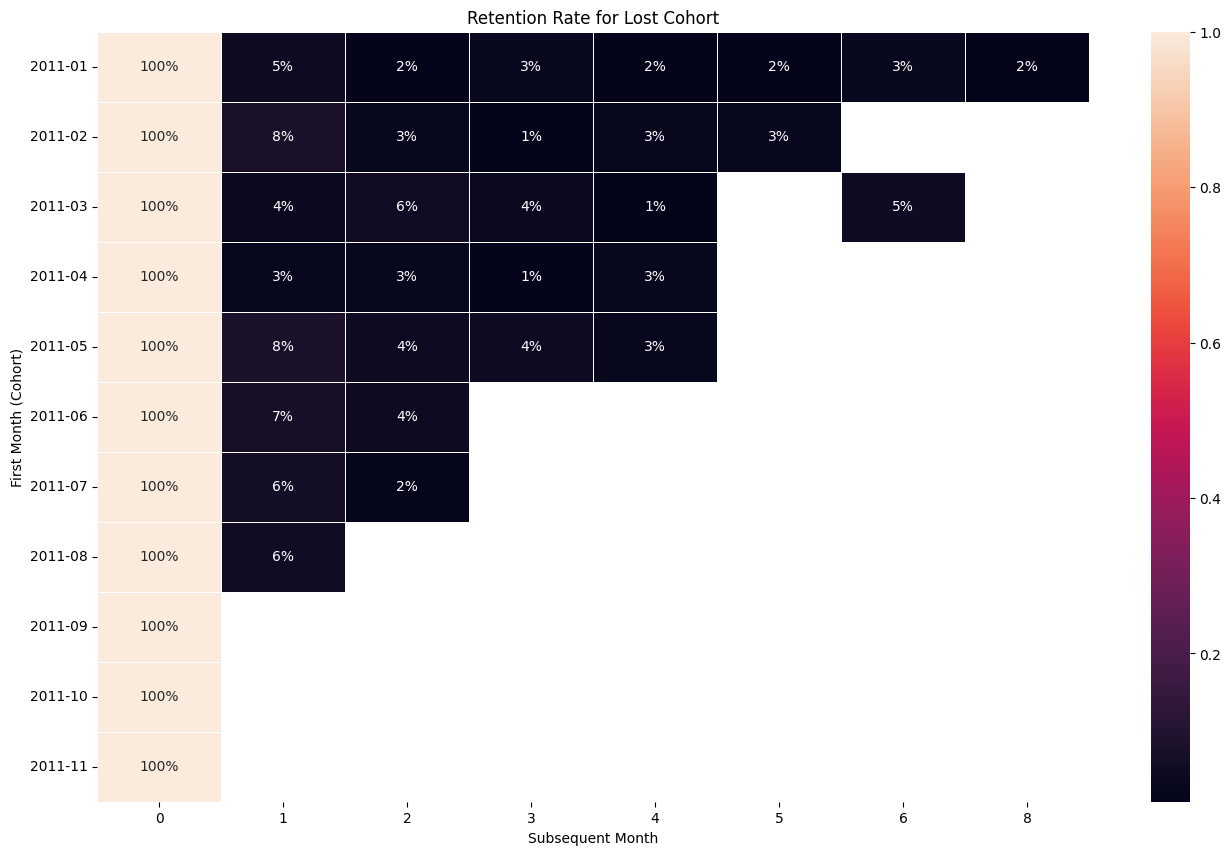

In [107]:
# Định dạng lại index và columns để hiển thị đẹp hơn trên heatmap
retention_matrix_lost.index = retention_matrix_lost.index.astype(str)
retention_matrix_lost.columns = retention_matrix_lost.columns.astype(str)

print("Retention Matrix (in %):")
print(retention_matrix_lost.round(3) * 100)

# Trực quan hóa ma trận giữ chân khách hàng (Retention Matrix) bằng heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(retention_matrix_lost, annot=True, fmt='.0%', cmap='rocket', linewidths=0.5, linecolor='white')
plt.title('Retention Rate for Lost Cohort')
plt.xlabel('Subsequent Month')
plt.ylabel('First Month (Cohort)')
plt.yticks(rotation=0)
plt.show()

**Nhận xét**: Phân tích Cohort năm 2011 cho thấy sự khác biệt rõ rệt về hành vi và giá trị dài hạn giữa các phân khúc khách hàng. Nhóm VIP duy trì tỷ lệ giữ chân cao ngay từ tháng đầu và tiếp tục mua sắm ổn định trong suốt năm, khẳng định vai trò là nhóm khách hàng cốt lõi của doanh nghiệp. Ngược lại, nhóm Lost có tỷ lệ quay lại rất thấp, phản ánh mức độ gắn kết yếu và xu hướng rời bỏ nhanh chóng. Trong khi đó, nhóm Loyal tuy không mua sắm thường xuyên ở giai đoạn đầu nhưng lại gia tăng mạnh tỷ lệ quay lại vào cuối năm, cho thấy đặc điểm mua sắm theo mùa vụ hoặc chu kỳ tái mua dài hơn. Nhóm Risk ghi nhận tỷ lệ giữ chân giảm liên tục, củng cố kết quả từ mô hình Random Forest rằng Recency là yếu tố ảnh hưởng quan trọng nhất đến khả năng rời bỏ của khách hàng. Nhìn chung, kết quả Cohort không chỉ xác thực hiệu quả của mô hình phân loại mà còn nhấn mạnh sự cần thiết của các chiến lược tiếp cận riêng cho từng phân khúc khách hàng nhằm tối ưu hóa tăng trưởng dài hạn.

## Kruskal-Wallis

- Giả thuyết không ($H_0$): Không có sự khác biệt về phân phối tỷ lệ giữ chân (Retention Rate) giữa các cụm khách hàng. Nói cách khác, các cụm khách hàng (VIP, Loyal, Risk, Lost) đều có khả năng quay lại mua hàng như nhau; mọi sự khác biệt quan sát được trên đồ thị chỉ là do ngẫu nhiên.
- Giả thuyết thay thế ($H_1$): Có sự khác biệt có ý nghĩa thống kê về phân phối tỷ lệ giữ chân giữa ít nhất hai cụm khách hàng. Điều này có nghĩa là phân khúc khách hàng thực sự ảnh hưởng đến hành vi quay lại mua hàng của họ.

In [109]:
from scipy import stats
import pandas as pd
def get_retention_values(pivot_table):
    # Lấy các giá trị từ Index 1 trở đi (bỏ cột 100%) và loại bỏ các giá trị NaN
    values = pivot_table.iloc[:, 1:].values.flatten()
    return values[~pd.isna(values)]

# Trích xuất dữ liệu từ các bảng bạn đã vẽ Heatmap
vip_values = get_retention_values(retention_matrix_vip)      # Dữ liệu từ
loyal_values = get_retention_values(retention_matrix_loyal)  # Dữ liệu từ
risk_values = get_retention_values(retention_matrix_risk)    # Dữ liệu từ
lost_values = get_retention_values(retention_matrix_lost)    # Dữ liệu từ

# Thực hiện kiểm định Kruskal-Wallis
stat, p_value = stats.kruskal(vip_values, loyal_values, risk_values, lost_values)

print(f"Kruskal-Wallis Statistic: {stat:.4f}")
print(f"p-value: {p_value:.10f}")

if p_value < 0.05:
    print("Kết luận: Bác bỏ H0. Có sự khác biệt có ý nghĩa thống kê về tỷ lệ giữ chân giữa 4 nhóm.")
else:
    print("Kết luận: Chưa đủ bằng chứng để bác bỏ H0.")

Kruskal-Wallis Statistic: 138.9306
p-value: 0.0000000000
Kết luận: Bác bỏ H0. Có sự khác biệt có ý nghĩa thống kê về tỷ lệ giữ chân giữa 4 nhóm.


In [110]:
# Trích xuất giá trị retention (từ cột thứ 2 trở đi) và loại bỏ các ô trống (NaN)
lost_values = retention_matrix_lost.iloc[:, 1:].values.flatten()
lost_values = lost_values[~np.isnan(lost_values)]

vip_values = retention_matrix_vip.iloc[:, 1:].values.flatten()
vip_values = vip_values[~np.isnan(vip_values)]

# Làm tương tự cho Loyal và Risk...
loyal_values = retention_matrix_loyal.iloc[:, 1:].values.flatten()
loyal_values = loyal_values[~np.isnan(loyal_values)]

risk_values = retention_matrix_risk.iloc[:, 1:].values.flatten()
risk_values = risk_values[~np.isnan(risk_values)]


# Sau đó mới bỏ vào hàm kiểm định
from scipy import stats
stat, p_value = stats.kruskal(vip_values, loyal_values, risk_values, lost_values)

In [111]:
import numpy as np
from scipy import stats
import pandas as pd

# 1. Hàm hỗ trợ trích xuất dữ liệu Retention (loại bỏ cột Index 0 và NaN)
def get_clean_retention_data(matrix):
    # Lấy từ cột thứ 2 trở đi (vì cột đầu tiên luôn là 1.0 hay 100%)
    # Dùng flatten() để đưa toàn bộ bảng về một danh sách số duy nhất
    values = matrix.iloc[:, 1:].values.flatten()
    # Loại bỏ các giá trị NaN (nhóm nào lọc theo nhóm đó)
    return values[~np.isnan(values)]

# 2. Trích xuất dữ liệu sạch cho 4 nhóm của bạn
# Hãy đảm bảo các tên biến retention_matrix_... khớp với code bạn đã chạy trước đó
data_vip   = get_clean_retention_data(retention_matrix_vip)
data_loyal = get_clean_retention_data(retention_matrix_loyal)
data_risk  = get_clean_retention_data(retention_matrix_risk)
data_lost  = get_clean_retention_data(retention_matrix_lost)

# 3. Thực hiện kiểm định Kruskal-Wallis
# Kiểm định này so sánh trung vị của các nhóm để xem chúng có cùng một phân phối không
h_stat, p_val = stats.kruskal(data_vip, data_loyal, data_risk, data_lost)

# 4. Hiển thị kết quả một cách chuyên nghiệp
print("KẾT QUẢ KIỂM ĐỊNH KRUSKAL-WALLIS CHO RETENTION RATE")
print(f"H-statistic (Giá trị kiểm định): {h_stat:.4f}")
print(f"p-value (Mức ý nghĩa): {p_val:.10e}") # Hiển thị dạng số mũ vì p-val sẽ rất nhỏ

if p_val < 0.05:
    print("\nKẾT LUẬN: p-value < 0.05. Bác bỏ giả thuyết H0.")
    print("Có sự khác biệt có ý nghĩa thống kê về tỷ lệ giữ chân giữa 4 cụm khách hàng.")
else:
    print("\nKẾT LUẬN: p-value >= 0.05. Chưa đủ bằng chứng bác bỏ H0.")
    print("Sự khác biệt giữa các cụm có thể chỉ là do ngẫu nhiên.")

KẾT QUẢ KIỂM ĐỊNH KRUSKAL-WALLIS CHO RETENTION RATE
H-statistic (Giá trị kiểm định): 138.9306
p-value (Mức ý nghĩa): 6.4274622893e-30

KẾT LUẬN: p-value < 0.05. Bác bỏ giả thuyết H0.
Có sự khác biệt có ý nghĩa thống kê về tỷ lệ giữ chân giữa 4 cụm khách hàng.


## Conclusion 3
- Bác bỏ giả thuyết $H_0$: Kết quả này cho phép bác bỏ hoàn toàn giả thuyết cho rằng tỷ lệ giữ chân khách hàng phân bổ đồng đều giữa các nhóm.Xác thực mô hình: Giá trị $H$ cao (138.93) chứng minh sự phân tách cực kỳ mạnh mẽ giữa các cụm. Điều này khẳng định rằng việc sử dụng Random Forest để dự báo dựa trên các đặc trưng RFM không chỉ đúng về mặt kỹ thuật (độ chính xác 98%) mà còn phản ánh chính xác sự khác biệt bản chất trong lòng trung thành của khách hàng theo thời gian.
- Insight kinh doanh: Sự khác biệt này là có ý nghĩa thống kê, nghĩa là doanh nghiệp hoàn toàn có thể tin tưởng vào việc áp dụng các chính sách chăm sóc riêng biệt: dồn lực bảo vệ nhóm VIP (với sức sống bền bỉ) và thận trọng khi đầu tư vào nhóm Lost (với hành vi rời bỏ đã được chứng minh).